# Assignment 4: Regularization 

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?

- *The intuition is that there is a "charge" for the model or a "buying" of larger slope coefficients that boosts error. By penalizing the mean squared error, it is increased in proportion to the amount of coefficient "purchased". The absolute value penalty is LASSO, which forces the model to pick more predictive variables and reduce the size of coefficients, resulting in interpretable and reliable models.*

2. How does regularization provide a way of exploring the bias-variance trade-off?

- *It introduces a tuning parameter that controls model complexity. Increasing the regularization strength (like large alpha values) increases bias but reduces variance, while decreasing it lowers bias but increases variance. By selecting a regularization parameter (like cross-validation), bias and variance can be balanced to have the best performance.*

3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?

- *LASSO sends coefs to zero as alpha increases, removing variables from the model and selecting a model specification for you ("zeros out" variables). Ridge smoothly shrinks all teh coefs towards zero, but never removes a variable completely.Typically, Ridge performs better, while LASSO provides more interpretable results.*
  
4. How do we typically scale variables for use in regularized regression? Why?

- *Variables are scaled using standardization, where you subtract the training mean and divide by the training standard deviation. This is done so that all features are on the same scale before applying regularization. Since methods discusses (like LASSO) penalize the size of coefficients, it is good practice to ensure that the penalty is applied fairly across all variables.*

5. How is the penalty $\alpha$ typically selected?

- *Alpha is selected using cross-validation. A range of possible values is tested, and for each one, the model computes the validation error using k-fold cross-validation. The value of alpha that minimizes the cross-validated error is chosen as the optimal penalty (stored as model.alpha_).*
  
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

- *No, the penalty term is not included when evaluating cross-validated MSE. While the model is trained using a loss function that includes the penalty, cross-validation evaluates performance using only the prediction error (MSE). This is because we want to measure how well the model predicts unseen data, and the penalty term is only used to control model complexity during training, not to assess predictive accuracy.*

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

## Question 2 
1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

df = pd.read_csv('./data/cars_hw.csv')
df.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [49]:
# Calculate the age of each car
df['Age'] = 2026 - df['Make_Year']

In [50]:
X = df[['Mileage_Run', 'Age']]
X.head()

,Mileage_Run,Age
0,44611,9
1,20305,10
2,29540,7
3,35680,9
4,25126,9


In [53]:
# third degree poly expander
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)
poly_names = poly.get_feature_names_out(['Mileage_Run', 'Age'])

# z-score normalization
scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly)

y = df['Price']
alpha_grid = np.logspace(2, 5, 50)
model = LassoCV(cv=10, 
                alphas=alpha_grid,
                random_state=100,
                max_iter=1_000_000)
model = model.fit(X_poly_scaled, y)

alpha_star = model.alpha_

Optimal cost hyperparameter: 1264.8552168552958


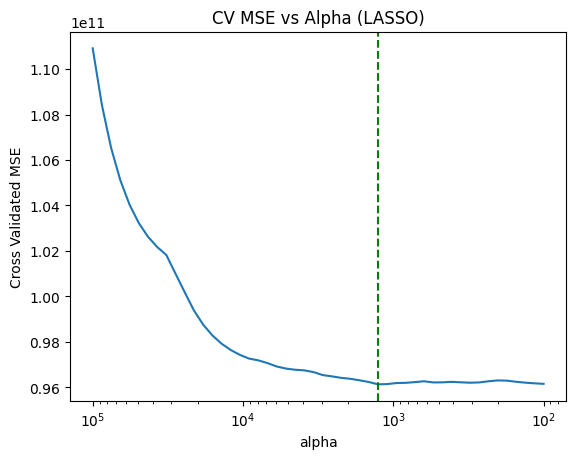

In [55]:
mean_mse = np.mean(model.mse_path_, axis=1)

sns.lineplot(x=model.alphas_, y=mean_mse)

plt.axvline(x=alpha_star, color='green', linestyle='--', linewidth=1.5)

plt.xscale("log")
plt.gca().invert_xaxis()

plt.xlabel("alpha")
plt.ylabel("Cross Validated MSE")
plt.title("CV MSE vs Alpha (LASSO)")

print(f'Optimal cost hyperparameter: {alpha_star}')

plt.show()

Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?

In [56]:
model = LinearRegression()
model.fit(X_poly_scaled, df['Price'])

coefs = pd.Series(model.coef_, index=feature_names)
coefs['Mileage_Run Age']

np.float64(-1671212.3563918832)

- The sign of the interaction is negative (as mileage and age increase, price decreases more)

 Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)

In [58]:
from sklearn.linear_model import LassoCV

alphas = np.logspace(1, 3, 20)

lasso_cv = LassoCV(alphas=alphas, cv=20, random_state=100, max_iter=1_000_000)
lasso_cv.fit(X_poly_scaled, df['Price'])

print("Best alpha:", lasso_cv.alpha_)

lasso_coefs = pd.Series(lasso_cv.coef_, index=feature_names)
lasso_coefs

Best alpha: 88.58667904100822


Mileage_Run          7.790762e+05
Age                 -1.339534e+05
Mileage_Run^2       -2.015634e+05
Mileage_Run Age     -1.322419e+06
Age^2                0.000000e+00
Mileage_Run^3       -4.240952e+04
Mileage_Run^2 Age    2.715062e+05
Mileage_Run Age^2    5.415432e+05
Age^3                1.374220e+04
dtype: float64

Plot the cross-validated MSE by $\alpha$.

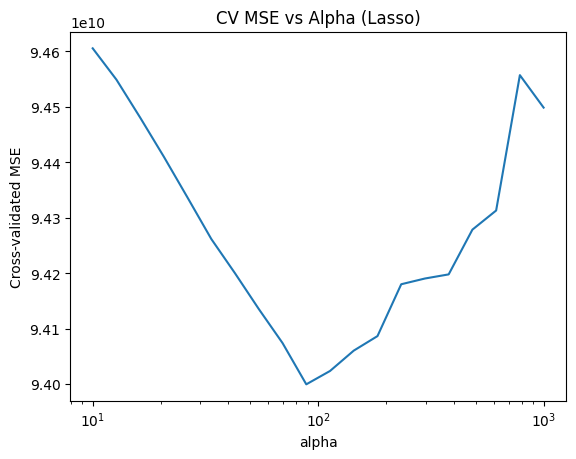

In [59]:
# Mean MSE across folds for each alpha
mean_mse = np.mean(lasso_cv.mse_path_, axis=1)

plt.figure()
plt.plot(lasso_cv.alphas_, mean_mse)

plt.xscale('log')  
plt.xlabel('alpha')
plt.ylabel('Cross-validated MSE')
plt.title('CV MSE vs Alpha (Lasso)')
plt.show()

Plot the coefficient paths by $\alpha$.

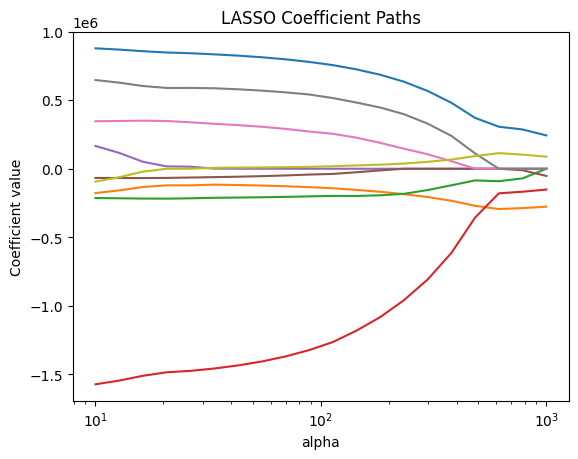

In [61]:
from sklearn.linear_model import Lasso

#loop over alphas and store coefs
coefs = []

for a in alphas:
    model = Lasso(alpha=a, max_iter=1_000_000)
    model.fit(X_poly_scaled, df['Price'])
    coefs.append(model.coef_)

coefs = np.array(coefs)

#plot
plt.figure()

for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i])

plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Coefficient value')
plt.title('LASSO Coefficient Paths')

plt.show()

Which features are actually selected? What proportion are set equal to zero?

In [62]:
# which features are selected?
feature_names = poly.get_feature_names_out(['Mileage_Run', 'Age'])
lasso_coefs = pd.Series(lasso_cv.coef_, index=feature_names)

selected = lasso_coefs[lasso_coefs != 0]
print(selected)

# which feature are zero?
zero_coefs = lasso_coefs[lasso_coefs == 0]
print(len(zero_coefs))

# proportion of zero
prop_zero = np.mean(lasso_coefs == 0)
print(prop_zero)

Mileage_Run          7.790762e+05
Age                 -1.339534e+05
Mileage_Run^2       -2.015634e+05
Mileage_Run Age     -1.322419e+06
Mileage_Run^3       -4.240952e+04
Mileage_Run^2 Age    2.715062e+05
Mileage_Run Age^2    5.415432e+05
Age^3                1.374220e+04
dtype: float64
1
0.1111111111111111


- All features are selected except for Age^2, which is set equal to zero by the LASSO model. This means that 1 out of 9 coefficients (approximately 11.1%) are eliminated, indicating that LASSO performs limited feature selection in this case.

Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [63]:
linear_coefs = pd.Series(model.coef_, index=feature_names)
lasso_coefs = pd.Series(lasso_cv.coef_, index=feature_names)

comparison = pd.DataFrame({
    'Linear': linear_coefs,
    'LASSO': lasso_coefs
})

comparison

,Linear,LASSO
Mileage_Run,242953.216388,7.790762e+05
Age,-276500.895776,-1.339534e+05
Mileage_Run^2,-0.000000,-2.015634e+05
Mileage_Run Age,-151598.545767,-1.322419e+06
Age^2,-0.000000,0.000000e+00
Mileage_Run^3,-52410.347536,-4.240952e+04
Mileage_Run^2 Age,-0.000000,2.715062e+05
Mileage_Run Age^2,-0.000000,5.415432e+05
Age^3,87796.740706,1.374220e+04


- Yes, several coefficients increase in magnitude from linear regression to LASSO. For example, Mileage_Run, Mileage_Run Age, Mileage_Run^2, and other higher-order terms have larger absolute values under LASSO than in the linear regression model. However, no coefficients change sign; all variables retain the same positive or negative direction across both models

## Question 3

Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.

In [130]:
df = pd.read_csv("./data/heart_failure_clinical_records_dataset.csv")
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [131]:
X_num = df[["age", "ejection_fraction", "serum_creatinine"]]
y = df['DEATH_EVENT']
X_num.head()

,age,ejection_fraction,serum_creatinine
0,75.0,20,1.9
1,55.0,38,1.1
2,65.0,20,1.3
3,50.0,20,1.9
4,65.0,20,2.7


In [132]:
# third degree poly expander
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X_num)
poly_names = poly.get_feature_names_out(['age', 'ejection_fraction', 'serum_creatinine'])

# z-score normalization
scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly)
X_poly_scaled = pd.DataFrame(X_poly_scaled, columns=poly_names)

In [133]:
# dummy variables
X_dummy = df[['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']]
X_dummy.head()

,anaemia,diabetes,high_blood_pressure,smoking
0,0,0,1,0
1,0,0,0,0
2,0,0,0,1
3,1,0,0,0
4,1,1,0,0


In [134]:
dummy_poly = PolynomialFeatures(
    degree=2, 
    include_bias=False, 
    interaction_only=True
    )
X_dummy_int = dummy_poly.fit_transform(X_dummy)
dummy_names = dummy_poly.get_feature_names_out(['anaemia', 'diabetes', 'high_blood_pressure', 'smoking'])   
X_dummy_int = pd.DataFrame(X_dummy_int, columns=dummy_names)
X_dummy_int.head()

,anaemia,diabetes,high_blood_pressure,smoking,anaemia diabetes,anaemia high_blood_pressure,anaemia smoking,diabetes high_blood_pressure,diabetes smoking,high_blood_pressure smoking
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [135]:
X_poly_scaled = pd.DataFrame(X_poly_scaled, columns=poly_names)
X = pd.concat([X_poly_scaled, X_dummy_int], axis=1)
X.head()

,age,ejection_fraction,serum_creatinine,age^2,age ejection_fraction,age serum_creatinine,ejection_fraction^2,ejection_fraction serum_creatinine,serum_creatinine^2,age^3,...,anaemia,diabetes,high_blood_pressure,smoking,anaemia diabetes,anaemia high_blood_pressure,anaemia smoking,diabetes high_blood_pressure,diabetes smoking,high_blood_pressure smoking
0,1.192945,-1.530560,0.490057,1.177180,-0.939354,0.777328,-1.197120,-0.287340,0.073541,1.124026,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.491279,-0.007077,-0.284552,-0.539187,-0.267742,-0.365953,-0.146835,-0.214284,-0.220393,-0.562311,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.350833,-1.530560,-0.090900,0.252982,-1.167019,-0.031334,-1.197120,-0.518041,-0.161606,0.152154,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.912335,-1.530560,0.490057,-0.885761,-1.508517,0.115061,-1.197120,-0.287340,0.073541,-0.835393,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.350833,-1.530560,1.264666,0.252982,-1.167019,1.237428,-1.197120,0.020262,0.524239,0.152154,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [136]:
linear_model = LinearRegression()
linear_model = linear_model.fit(X, y)

print(f'Model intercept: {linear_model.intercept_}')
pd.DataFrame({'variable':linear_model.feature_names_in_, 'coefficient':linear_model.coef_ })

Model intercept: 0.33036410294994883


,variable,coefficient
0,age,1.539156
1,ejection_fraction,-2.192494
2,serum_creatinine,-0.853588
3,age^2,-3.678654
4,age ejection_fraction,-0.600918
5,age serum_creatinine,1.841563
6,ejection_fraction^2,3.430976
7,ejection_fraction serum_creatinine,2.673394
8,serum_creatinine^2,-2.647041
9,age^3,1.993135


Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?

In [137]:
print(f'Model intercept: {linear_model.intercept_}')

# coefficient table
coef_table = pd.DataFrame({
    'variable': linear_model.feature_names_in_,
    'coefficient': linear_model.coef_
})

coef_table

Model intercept: 0.33036410294994883


,variable,coefficient
0,age,1.539156
1,ejection_fraction,-2.192494
2,serum_creatinine,-0.853588
3,age^2,-3.678654
4,age ejection_fraction,-0.600918
5,age serum_creatinine,1.841563
6,ejection_fraction^2,3.430976
7,ejection_fraction serum_creatinine,2.673394
8,serum_creatinine^2,-2.647041
9,age^3,1.993135


- There are several sign patterns that appear counterintuitive. For example, age has a positive coefficient while age^2 is negative and age^3 is positive, and similar sign changes appear in ejection_fraction. These patterns are not necessarily contradictions but reflect the nonlinear relationships in the data. The inclusion of higher-order polynomial terms and interactions allows the model to capture curvature and changing effects across different values of the variables. As a result, the overall effect of a variable depends on the combination of all its terms, rather than any single coefficient.

Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(5,5,30)` to find the cost parameter)

In [138]:
alphas = np.logspace(-3, 0, 15) 

scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

lasso_cv = LassoCV(
    alphas=alphas,
    cv=20,
    random_state=100,
    max_iter=1_000_000
)

lasso_cv.fit(X_scaled, y)

print("Best alpha:", lasso_cv.alpha_)

lasso_coefs = pd.DataFrame({
    "variable": X.columns,
    "coefficient": lasso_cv.coef_
})

lasso_coefs

Best alpha: 0.0071968567300115215


,variable,coefficient
0,age,-0.000000
1,ejection_fraction,-0.301037
2,serum_creatinine,0.112096
3,age^2,0.000000
4,age ejection_fraction,-0.000000
5,age serum_creatinine,0.000000
6,ejection_fraction^2,0.000000
7,ejection_fraction serum_creatinine,0.000000
8,serum_creatinine^2,-0.000000
9,age^3,0.114646


- I used a different logspace than the suggested (5, 5, 30) because it was giving me single alpha values with all the coefficients shrunk to zero. I am not sure if this is what you wanted, but it made all of my graphs just vertical/straight lines, which is why I decided to change it.

Plot the cross-validated MSE by $\alpha$.

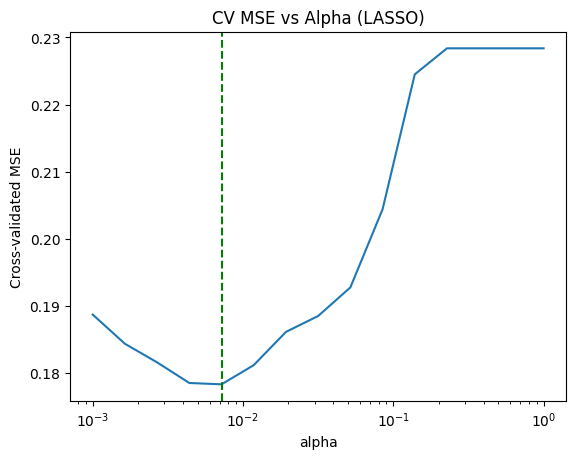

In [139]:
import matplotlib.pyplot as plt

mean_mse = np.mean(lasso_cv.mse_path_, axis=1)
order = np.argsort(lasso_cv.alphas_)

plt.figure()
plt.plot(lasso_cv.alphas_[order], mean_mse[order])
plt.axvline(x=lasso_cv.alpha_, color='green', linestyle='--', linewidth=1.5)

plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Cross-validated MSE')
plt.title('CV MSE vs Alpha (LASSO)')
plt.show()

Plot the coefficient paths by $\alpha$.

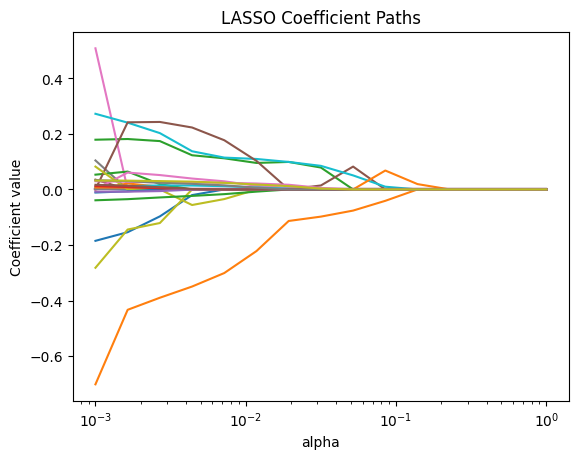

In [140]:
coefs = []

for a in alphas:
    model = Lasso(alpha=a, max_iter=1_000_000)
    model.fit(X_scaled, y)
    coefs.append(model.coef_)

coefs = np.array(coefs)

plt.figure()

for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i])

plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Coefficient value')
plt.title('LASSO Coefficient Paths')

plt.show()

Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [141]:
lasso_series = pd.Series(lasso_cv.coef_, index=X.columns)

selected = lasso_series[lasso_series != 0]
zero_coefs = lasso_series[lasso_series == 0]
prop_zero = np.mean(lasso_series == 0)

print(selected)
print(len(zero_coefs))
print(prop_zero)

ejection_fraction                      -0.301037
serum_creatinine                        0.112096
age^3                                   0.114646
ejection_fraction^3                     0.177164
ejection_fraction^2 serum_creatinine    0.029248
serum_creatinine^3                     -0.034704
anaemia                                 0.011692
smoking                                -0.016951
anaemia diabetes                        0.000451
diabetes high_blood_pressure            0.023781
diabetes smoking                        0.014745
high_blood_pressure smoking             0.023852
dtype: float64
17
0.5862068965517241


In [143]:
linear_series = pd.Series(linear_model.coef_, index=X.columns)

comparison = pd.DataFrame({
    "Linear": linear_series,
    "LASSO": lasso_series
})

comparison

,Linear,LASSO
age,1.539156,-0.000000
ejection_fraction,-2.192494,-0.301037
serum_creatinine,-0.853588,0.112096
age^2,-3.678654,0.000000
age ejection_fraction,-0.600918,-0.000000
age serum_creatinine,1.841563,0.000000
ejection_fraction^2,3.430976,0.000000
ejection_fraction serum_creatinine,2.673394,0.000000
serum_creatinine^2,-2.647041,-0.000000
age^3,1.993135,0.114646


- LASSO keeps 12 features nonzero: ejection_fraction, serum_creatinine, age^3, etc...
- 17 of the 29 coefficients are set to zero, with the proportion being 58%. This means that 58% of the features are eliminated.
- Most coefficients shrink in magnitude under LASSO, which is expected from regularization. Only anaemia increases slightly in magnitude, from about 0.0081 in the linear model to about 0.0117 in LASSO. A few coefficients do change sign when moving from linear regression to LASSO. This occurs for: serum_creatinine, ejection_fraction^2 serum_creatinine, and serum_creatinine^3
- Overall, the LASSO sign patterns seem more reasonable. The unregularized linear model includes many polynomial and interaction terms, so it could be more unstable; this would make individual coefficients look noisy/counterintuitive. LASSO removes a lot of those weaker terms and leaves a much sparser model (the coefficients are more stable and easier to interpret).
- This fits the bias-variance trade-off. The ordinary linear regression with many higher-order powers and interactions has low bias but high variance; it is flexible, but its coefficients can become hard to interpret. LASSO adds some bias by shrinking coefficients toward zero, but in return it reduces variance substantially. That makes the model less sensitive to noise in the sample and often produces cleaner, more interpretable coefficient patterns.

## Question 4

1. **To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?**

The ridge regression objective function is the mean squared error plus a penalty on the squared coefficients:

$$
\frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^p b_j^2
$$

where:
- $y_i$ is the observed value
- $\hat{y}_i$ is the predicted value
- $b_j$ are the model coefficients
- $\alpha$ is the regularization parameter controlling the strength of the penalty

2. **Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.**

Objective function:
$$
\frac{1}{n} \sum_{i=1}^n (y_i - b_0 - b_1 x_i)^2 + \alpha b_1^2
$$

First-order conditions:
$$
\frac{\partial}{\partial b_0} = -\frac{2}{n} \sum (y_i - b_0 - b_1 x_i) = 0
$$

$$
\frac{\partial}{\partial b_1} = -\frac{2}{n} \sum x_i (y_i - b_0 - b_1 x_i) + 2\alpha b_1 = 0
$$

Solving:

$$
b_1 = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2 + n\alpha}
$$

$$
b_0 = \bar{y} - b_1 \bar{x}
$$

3. **How does increasing $\alpha$ change the slope coefficient?**

Increasing alpha increases the penalty on the squared coefficient $b_1^2$, which causes the slope coefficient $b_1$ to shrink toward zero.

From the ridge solution:
$$
b_1 = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2 + n\alpha}
$$

As alpha increases, the denominator becomes larger, so $b_1$ becomes smaller in magnitude.

Increasing alpha reduces the magnitude of the slope coefficient, shrinks the model toward a flatter (less steep) line, and increases bias but reduces variance.

4. **If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?**

With the LASSO penalty, the objective function becomes

$$
\frac{1}{n}\sum_{i=1}^n (y_i-b_0-b_1x_i)^2+\alpha |b_1|.
$$

The main challenge is that $|b_1|$ is not differentiable at $b_1=0$, so we cannot just take an ordinary derivative and solve the first-order conditions the same way we did for ridge regression.

For $b_1 \neq 0$, the derivative of $|b_1|$ is

$$
\frac{d}{db_1}|b_1| =
\begin{cases}
1, & b_1>0 \\
-1, & b_1<0
\end{cases}
$$

so the slope equation depends on the sign of $b_1$. This creates a kink at zero.

A key idea is that if the improvement in fit from using a nonzero slope is large enough, then the optimal $b_1$ will be positive or negative, and if the improvement in fit is too small to overcome the penalty, then it is optimal to set

$$
b_1=0.
$$

So under LASSO, it is optimal to set $b_1=0$ when the slope suggested by the data is small enough that the $L_1$ penalty dominates. This is why LASSO can produce exactly zero coefficients, unlike ridge regression, which usually only shrinks them toward zero.